# 3. Bathymetry from your data

**What this shows:** how to read bathymetry from a file, interpolate it onto the
model grid, extend it offshore and check the result.

**Prerequisites:** [2. Defining the model grid](02_model_grid.ipynb).

**You will learn:**

- what a *source* is and why it carries a coordinate reference system
- how `XBeachBathy` interpolates data onto the grid and writes XBeach files
- why XBeach needs a uniform depth offshore, and how the seaward extension provides it
- how to plot and check the model bathymetry

**Data used:** `bathy.tif`, a GeoTIFF of elevations (positive up) in WGS84.

## Setup

In [1]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
from rompy_xbeach.grid import RegularGrid

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "03_bathymetry"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)

## 1. The data source

Sources describe *where* data comes from and *how* to open it. rompy-xbeach sources
always know the data CRS, so data in geographic coordinates can be interpolated onto a
projected model grid. For a GeoTIFF the CRS is read from the file.

In [2]:
from rompy_xbeach.source import SourceGeotiff

source = SourceGeotiff(filename=DATA_DIR / "bathy.tif")
ds = source.open()
print(f"CRS: {ds.rio.crs}")
ds

CRS: EPSG:4326


<xarray.Dataset> Size: 130kB
Dimensions:      (x: 176, y: 180)
Coordinates:
  * x            (x) float64 1kB 115.6 115.6 115.6 115.6 ... 115.6 115.6 115.6
  * y            (y) float64 1kB -32.65 -32.65 -32.65 ... -32.61 -32.61 -32.61
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    data         (y, x) float32 127kB ...

Plotting the source with the grid on top confirms the grid covers the surf zone and
the beach.

Text(0.5, 1.0, 'Source elevation and model grid')

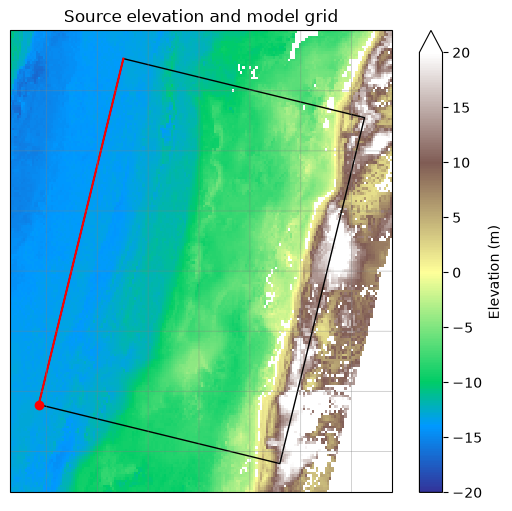

In [3]:
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": grid.projection})
ds.data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="terrain",
    vmin=-20,
    vmax=20,
    cbar_kwargs={"label": "Elevation (m)"},
)
grid.plot(
    ax=ax, grid_kwargs={"facecolor": "none", "edgecolor": "black"}, set_extent=False
)
ax.set_title("Source elevation and model grid")

Other formats, including NetCDF, XYZ point clouds, intake catalogues and in-memory
xarray datasets, use other source classes with the same interface. See
[Data sources](../examples/data_sources.ipynb).

## 2. Interpolating onto the grid

`XBeachBathy` combines the source with an interpolator. `posdwn=False` states that
the data are elevations (negative underwater), and the same convention is passed to
XBeach.

In [4]:
from rompy_xbeach.data.bathy import XBeachBathy
from rompy_xbeach.interpolate import RegularGridInterpolator

bathy = XBeachBathy(
    source=source,
    posdwn=False,
    interpolator=RegularGridInterpolator(
        kwargs={"method": "linear", "fill_value": None}
    ),
)

`get()` writes the XBeach grid and depth files and returns them together with the
grid actually used. You rarely call it yourself, since `ModelRun` does it, but it is
handy for checking the bathymetry before building a model.

In [5]:
xfile, yfile, depfile, model_grid = bathy.get(destdir=OUT_DIR, grid=grid)
print([f.name for f in (xfile, yfile, depfile)])

['xdata.txt', 'ydata.txt', 'bathy.txt']


The `xbeach` accessor reads the depth file back and plots it on the model grid.

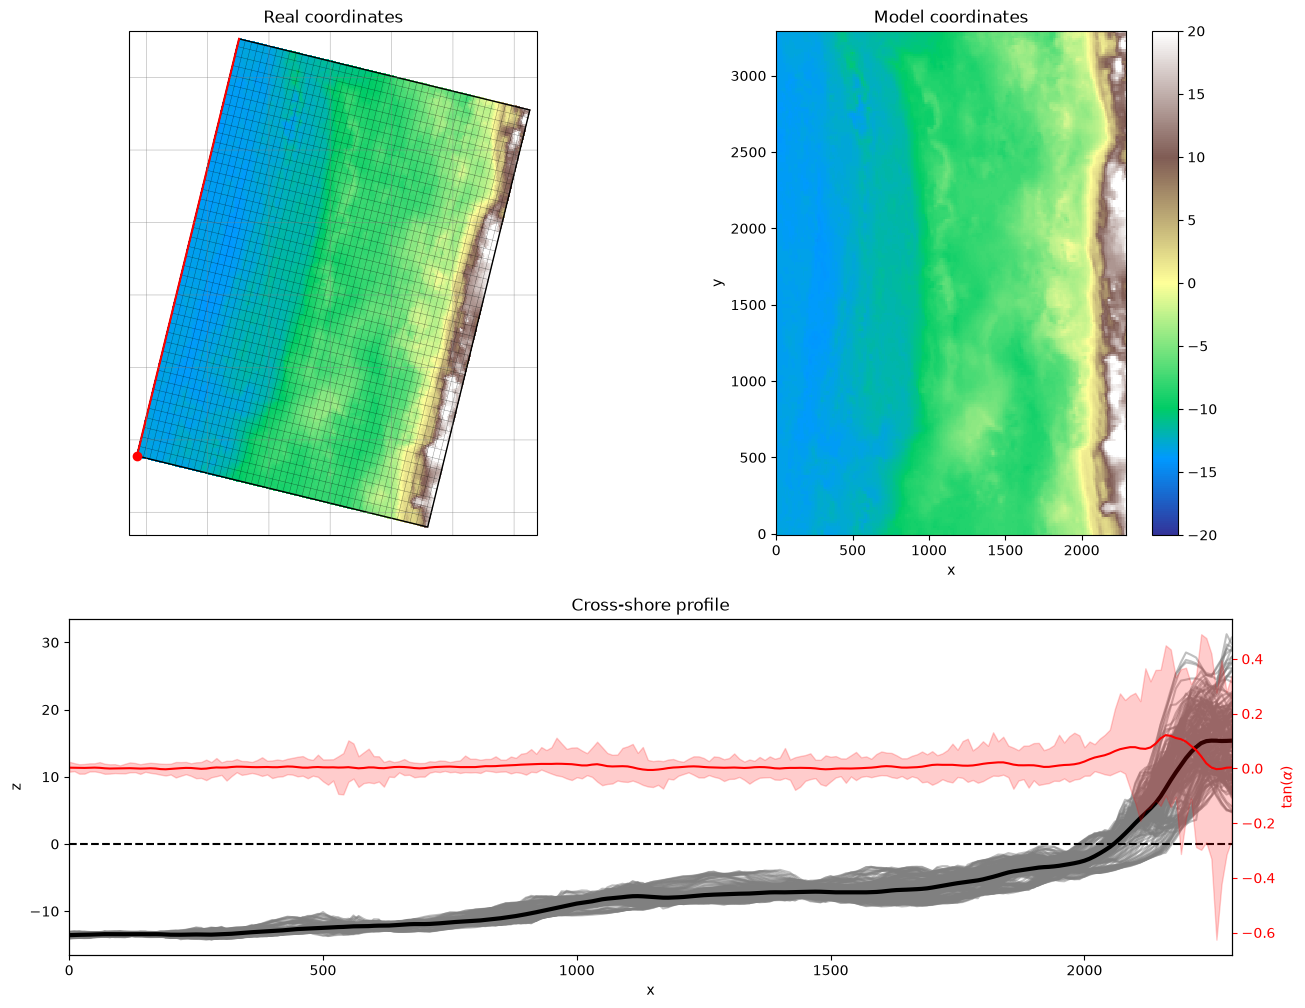

In [6]:
dset = xr.Dataset.xbeach.from_xbeach(depfile, model_grid)
dset.xbeach.plot_model_bathy(model_grid, posdwn=False)

## 3. Extending the domain offshore

XBeach expects a uniform depth along the offshore boundary, and the source data
may not reach deep enough. `SeawardExtensionLinear` adds cells offshore that slope
down to a target depth.

In [7]:
from rompy_xbeach.data.bathy import SeawardExtensionLinear

bathy_extended = XBeachBathy(
    source=source,
    posdwn=False,
    interpolator=RegularGridInterpolator(
        kwargs={"method": "linear", "fill_value": None}
    ),
    extension=SeawardExtensionLinear(depth=25.0, slope=0.05),
)
xfile, yfile, depfile, extended_grid = bathy_extended.get(destdir=OUT_DIR, grid=grid)
print(f"Grid points before: {model_grid.nx} x {model_grid.ny}")
print(f"Grid points after:  {extended_grid.nx} x {extended_grid.ny}")

Grid points before: 230 x 220
Grid points after:  254 x 220


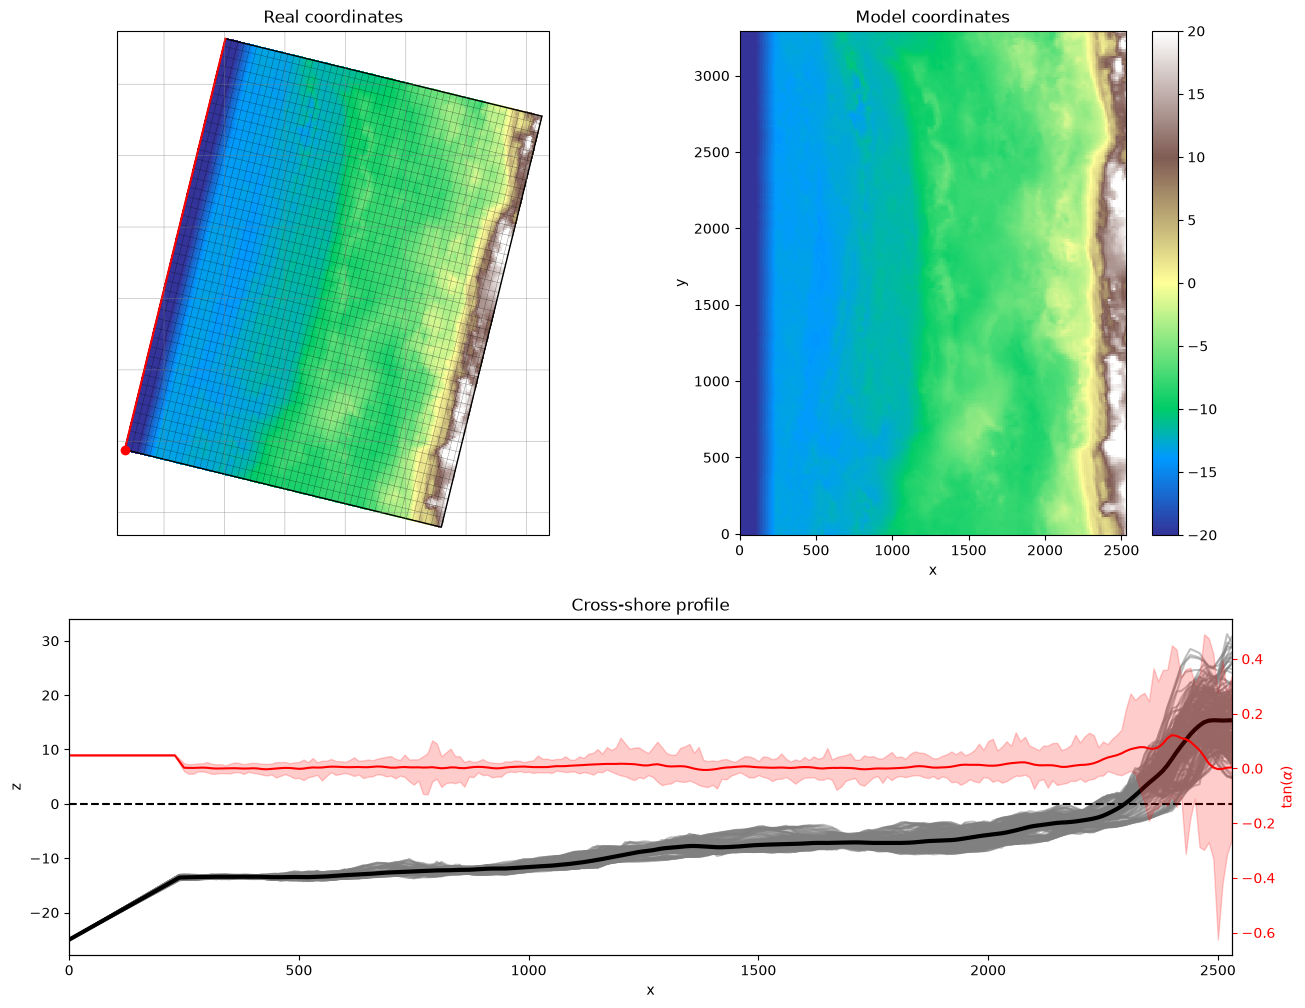

In [8]:
dset = xr.Dataset.xbeach.from_xbeach(depfile, extended_grid)
dset.xbeach.plot_model_bathy(extended_grid, posdwn=False)

`left` and `right` also widen the grid by copying the edge profiles sideways, which
keeps lateral boundary effects away from the area of interest. Both options are
compared in [Bathymetry options](../examples/bathymetry_options.ipynb).

## 4. The XBeach parameters

Inside a `Config`, the bathymetry contributes the depth convention and file, and the
(possibly extended) grid contributes its own parameters.

In [9]:
params = {**bathy_extended.params, **extended_grid.params, "depfile": depfile.name}
for key, value in params.items():
    print(f"{key} = {value}")

posdwn = -1
vardx = 0
nx = 253
ny = 219
dx = 10.0
dy = 15.0
xori = 367911.1535344968
yori = 6387680.577519925
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs
depfile = bathy.txt


## Summary

- A source opens the data and knows its CRS. `XBeachBathy` interpolates it onto the
  grid.
- Use `posdwn` to match the sign convention of your data.
- A seaward extension gives XBeach the uniform offshore depth it expects.

**Next:** [4. Adding forcing: waves, wind and water levels](04_forcing.ipynb).